# BP coverage analysis in ARCHS4 and GTEx

💡 **Environment:** `clamp-analyses`  

This notebook analyzes the proportion of biological processes (BP) that are represented in CLAMP models with different BP coverage settings.

Two sampling strategies are compared:
- **bp_coverage**: Study-based sampling (samples are selected by study/series)
- **bp_coverage_rs**: Random sampling (samples are selected randomly)

GTEx results are also included for comparison.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from pyprojroot.here import here
import re

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
readRDS = ro.r["readRDS"]
as_matrix = ro.r["as.matrix"]

import matplotlib.pyplot as plt

In [2]:
# Default thresholds for data exploration cells below
auc_threshold = 0.6
fdr_threshold = 0.1

## Load BP reference data for ARCHS4

In [3]:
bp_matched_path = here("output/archs4/BP_matched.rds")
bp_matched_archs4_r = readRDS(str(bp_matched_path))

r_rownames = ro.r.rownames(bp_matched_archs4_r)
r_colnames = ro.r.colnames(bp_matched_archs4_r)

bp_matched_dense = as_matrix(bp_matched_archs4_r)

with localconverter(ro.default_converter + pandas2ri.converter):
    data_values = ro.conversion.rpy2py(bp_matched_dense)

bp_matched_archs4_df = pd.DataFrame(
    data=data_values,
    index=list(r_rownames) if r_rownames is not ro.NULL else None,
    columns=list(r_colnames) if r_colnames is not ro.NULL else None
)

display(bp_matched_archs4_df.head())
bp_archs4_unique = bp_matched_archs4_df.columns.unique()
bp_archs4_unique[0:5]

total_bps_archs4 = len(bp_archs4_unique)
print(f"Total unique biological processes in ARCHS4 reference: {total_bps_archs4}")

R callback write-console: Loading required package: Matrix
  


,BP_'De Novo' Post-Translational Protein Folding (GO:0051084),BP_2-Oxoglutarate Metabolic Process (GO:0006103),BP_3'-UTR-mediated mRNA Destabilization (GO:0061158),BP_3'-UTR-mediated mRNA Stabilization (GO:0070935),BP_3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),BP_ADP Catabolic Process (GO:0046032),BP_ATP Biosynthetic Process (GO:0006754),BP_ATP Metabolic Process (GO:0046034),BP_ATP Transport (GO:0015867),BP_Arp2/3 Complex-Mediated Actin Nucleation (GO:0034314),...,BP_Water Transport (GO:0006833),BP_Water-Soluble Vitamin Metabolic Process (GO:0006767),BP_Wound Healing (GO:0042060),"BP_Wound Healing, Spreading of Cells (GO:0044319)","BP_Wound Healing, Spreading of Epidermal Cells (GO:0035313)",BP_Xenobiotic Catabolic Process (GO:0042178),BP_Xenobiotic Transport (GO:0042908),BP_Zinc Ion Transmembrane Transport (GO:0071577),BP_Zinc Ion Transport (GO:0006829),BP_Zymogen Activation (GO:0031638)
A1BG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1BG-AS1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M-AS1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2ML1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Total unique biological processes in ARCHS4 reference: 3284


## Load BP reference data for GTEx

In [4]:
# Load GO_Biological_Process_2025_matched for GTEx
gtex_bp_path = here("output/gtex/GO_Biological_Process_2025_matched.rds")
bp_matched_gtex_r = readRDS(str(gtex_bp_path))

# Convert to DataFrame
bp_matched_dense = as_matrix(bp_matched_gtex_r)
r_rownames = ro.r.rownames(bp_matched_gtex_r)
r_colnames = ro.r.colnames(bp_matched_gtex_r)

with localconverter(ro.default_converter + pandas2ri.converter):
    data_values = ro.conversion.rpy2py(bp_matched_dense)

bp_matched_gtex_df = pd.DataFrame(
    data=data_values,
    index=list(r_rownames) if r_rownames is not ro.NULL else None,
    columns=list(r_colnames) if r_colnames is not ro.NULL else None
)

display(bp_matched_gtex_df.head())
bp_gtex_unique = bp_matched_gtex_df.columns.unique()
bp_gtex_unique[0:5]

total_bps_gtex = len(bp_gtex_unique)
print(f"Total unique biological processes in GTEx reference: {total_bps_gtex}")

,'De Novo' Post-Translational Protein Folding (GO:0051084),2-Oxoglutarate Metabolic Process (GO:0006103),3'-UTR-mediated mRNA Destabilization (GO:0061158),3'-UTR-mediated mRNA Stabilization (GO:0070935),3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),ADP Catabolic Process (GO:0046032),ATP Metabolic Process (GO:0046034),ATP Transport (GO:0015867),Arp2/3 Complex-Mediated Actin Nucleation (GO:0034314),B Cell Activation (GO:0042113),...,Vitamin Transport (GO:0051180),Water Transport (GO:0006833),Water-Soluble Vitamin Metabolic Process (GO:0006767),Wound Healing (GO:0042060),"Wound Healing, Spreading of Cells (GO:0044319)",Xenobiotic Catabolic Process (GO:0042178),Xenobiotic Transport (GO:0042908),Zinc Ion Transmembrane Transport (GO:0071577),Zinc Ion Transport (GO:0006829),Zymogen Activation (GO:0031638)
WASH7P,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RP11-34P13.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RP11-34P13.16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RP11-34P13.18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AP006222.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Total unique biological processes in GTEx reference: 3323


## Define summary file paths

In [5]:
output_dir = here("output/archs4")

# bp_coverage experiments (study-based sampling)
bp_coverage_files = {
    f"bp_coverage_{cov}_seed_{seed}": output_dir / f"bp_coverage_{cov}_seed_{seed}" / "CLAMPfull_BP" / "summary.csv"
    for cov in [1, 5, 10, 25, 50]
    for seed in [1, 2, 3]
}

# bp_coverage_rs experiments (random sampling)
bp_coverage_rs_files = {
    f"bp_coverage_rs{cov}_seed_{seed}": output_dir / f"bp_coverage_rs{cov}_seed_{seed}" / "CLAMPfull_BP" / "summary.csv"
    for cov in [1, 5, 10, 25, 50]
    for seed in [1, 2, 3]
}

print(f"bp_coverage files: {len(bp_coverage_files)}")
print(f"bp_coverage_rs files: {len(bp_coverage_rs_files)}")

bp_coverage files: 15
bp_coverage_rs files: 15


## Read and process bp_coverage (study-based sampling)

In [6]:
results_bp_coverage = []

for name, filepath in bp_coverage_files.items():
    if not filepath.exists():
        print(f"File not found: {filepath}")
        continue
    
    df = pd.read_csv(filepath, index_col=0)
    
    # Apply AUC and FDR filters
    df_filtered = df[(df["AUC"] > auc_threshold) & (df["FDR"] < fdr_threshold)]
    
    # Get unique BPs that pass the filter
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_archs4
    
    # Parse coverage and seed from name
    match = re.match(r"bp_coverage_(\d+)_seed_(\d+)", name)
    
    coverage = int(match.group(1))
    seed = int(match.group(2))

    results_bp_coverage.append({
        "name": name,
        "coverage": coverage,
        "seed": seed,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_archs4,
        "proportion_covered": proportion
    })
    
results_bp_coverage_df = pd.DataFrame(results_bp_coverage)
results_bp_coverage_df

,name,coverage,seed,n_unique_bps,total_bps,proportion_covered
0,bp_coverage_1_seed_1,1,1,76,3284,0.023143
1,bp_coverage_1_seed_2,1,2,272,3284,0.082826
2,bp_coverage_1_seed_3,1,3,205,3284,0.062424
3,bp_coverage_5_seed_1,5,1,112,3284,0.034105
4,bp_coverage_5_seed_2,5,2,50,3284,0.015225
5,bp_coverage_5_seed_3,5,3,50,3284,0.015225
6,bp_coverage_10_seed_1,10,1,143,3284,0.043544
7,bp_coverage_10_seed_2,10,2,245,3284,0.074604
8,bp_coverage_10_seed_3,10,3,241,3284,0.073386
9,bp_coverage_25_seed_1,25,1,75,3284,0.022838


## Read and process bp_coverage_rs (random sampling)

In [7]:
results_bp_coverage_rs = []

for name, filepath in bp_coverage_rs_files.items():
    if not filepath.exists():
        print(f"File not found: {filepath}")
        continue
    
    df = pd.read_csv(filepath, index_col=0)
    
    # Apply AUC and FDR filters
    df_filtered = df[(df["AUC"] > auc_threshold) & (df["FDR"] < fdr_threshold)]
    
    # Get unique BPs that pass the filter
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_archs4
    
    # Parse coverage and seed from name
    match = re.match(r"bp_coverage_rs(\d+)_seed_(\d+)", name)
    coverage = int(match.group(1))
    seed = int(match.group(2))
    
    results_bp_coverage_rs.append({
        "name": name,
        "coverage": coverage,
        "seed": seed,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_archs4,
        "proportion_covered": proportion
    })
    
results_bp_coverage_rs_df = pd.DataFrame(results_bp_coverage_rs)
results_bp_coverage_rs_df

,name,coverage,seed,n_unique_bps,total_bps,proportion_covered
0,bp_coverage_rs1_seed_1,1,1,155,3284,0.047199
1,bp_coverage_rs1_seed_2,1,2,108,3284,0.032887
2,bp_coverage_rs1_seed_3,1,3,141,3284,0.042935
3,bp_coverage_rs5_seed_1,5,1,64,3284,0.019488
4,bp_coverage_rs5_seed_2,5,2,47,3284,0.014312
5,bp_coverage_rs5_seed_3,5,3,68,3284,0.020706
6,bp_coverage_rs10_seed_1,10,1,75,3284,0.022838
7,bp_coverage_rs10_seed_2,10,2,61,3284,0.018575
8,bp_coverage_rs10_seed_3,10,3,88,3284,0.026797
9,bp_coverage_rs25_seed_1,25,1,77,3284,0.023447


## Load GTEx CLAMP data

In [8]:
gtex_seed_paths = [
    "output/gtex/bp_coverage_seed_1/CLAMPfull_BP/summary.csv",
    "output/gtex/bp_coverage_seed_2/CLAMPfull_BP/summary.csv",
    "output/gtex/bp_coverage_seed_3/CLAMPfull_BP/summary.csv",
]

results_gtex = []
for i, path in enumerate(gtex_seed_paths, start=1):
    filepath = here(path)
    df = pd.read_csv(filepath, index_col=0)
    df_filtered = df[(df["AUC"] > auc_threshold) & (df["FDR"] < fdr_threshold)]
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_gtex
    
    results_gtex.append({
        "name": f"GTEx_CLAMP_seed_{i}",
        "coverage": "gtex",
        "seed": i,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_gtex,
        "proportion_covered": proportion
    })

results_gtex_df = pd.DataFrame(results_gtex)
results_gtex_df

,name,coverage,seed,n_unique_bps,total_bps,proportion_covered
0,GTEx_CLAMP_seed_1,gtex,1,86,3323,0.025880
1,GTEx_CLAMP_seed_2,gtex,2,152,3323,0.045742
2,GTEx_CLAMP_seed_3,gtex,3,77,3323,0.023172


## BP Coverage Plots

Two filter conditions:
- **FDR < 0.05**, AUC > 0.6
- **FDR < 0.1**, AUC > 0.6

Each shown for study-based and random sampling, with two orderings:
1. Ordered by highest median coverage
2. Ordered by sample percentage (50%, 25%, 10%, 5%, 1%, GTEx)

In [9]:
from matplotlib.patches import Patch

def process_data(bp_coverage_files, bp_coverage_rs_files, gtex_seed_paths,
                 total_bps_archs4, total_bps_gtex, fdr_thr, auc_thr):
    """Process all data for a given FDR/AUC threshold combination."""
    
    def _process_files(files, pattern, total_bps):
        results = []
        for name, filepath in files.items():
            if not filepath.exists():
                continue
            df = pd.read_csv(filepath, index_col=0)
            df_f = df[(df["AUC"] > auc_thr) & (df["FDR"] < fdr_thr)]
            n_bps = len(df_f["pathway"].unique())
            match = re.match(pattern, name)
            results.append({
                "coverage": int(match.group(1)), "seed": int(match.group(2)),
                "n_unique_bps": n_bps, "total_bps": total_bps,
                "proportion_covered": n_bps / total_bps
            })
        return pd.DataFrame(results)
    
    study_df = _process_files(bp_coverage_files, r"bp_coverage_(\d+)_seed_(\d+)", total_bps_archs4)
    random_df = _process_files(bp_coverage_rs_files, r"bp_coverage_rs(\d+)_seed_(\d+)", total_bps_archs4)
    
    gtex_results = []
    for i, path in enumerate(gtex_seed_paths, start=1):
        filepath = here(path)
        df = pd.read_csv(filepath, index_col=0)
        df_f = df[(df["AUC"] > auc_thr) & (df["FDR"] < fdr_thr)]
        n_bps = len(df_f["pathway"].unique())
        gtex_results.append({
            "coverage": "gtex", "seed": i,
            "n_unique_bps": n_bps, "total_bps": total_bps_gtex,
            "proportion_covered": n_bps / total_bps_gtex
        })
    gtex_df = pd.DataFrame(gtex_results)
    
    return study_df, random_df, gtex_df


def plot_bp_coverage(results_archs4_df, results_gtex_df, title, archs4_color, order_by='median', ax=None):
    """Plot BP coverage boxplots."""
    results_plot = pd.concat([results_archs4_df, results_gtex_df], ignore_index=True)
    
    if order_by == 'median':
        coverage_medians = results_plot.groupby('coverage')['proportion_covered'].median().sort_values(ascending=False)
        coverage_order = coverage_medians.index.tolist()
    else:
        coverage_order = [50, 25, 10, 5, 1, "gtex"]
    
    labels = []
    colors = []
    for c in coverage_order:
        if c == "gtex":
            labels.append("GTEx CLAMP\n(100%)")
            colors.append('#e74c3c')
        else:
            labels.append(f"ARCHS4 CLAMP\n({c}%)")
            colors.append(archs4_color)
    
    grouped_data = [results_plot[results_plot['coverage'] == c]['proportion_covered'].values * 100 for c in coverage_order]
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    bp = ax.boxplot(
        grouped_data, positions=range(len(coverage_order)), widths=0.5,
        patch_artist=True, showfliers=True,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color='black'), capprops=dict(color='black')
    )
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_alpha(0.8)
    
    ax.set_ylabel("Proportion of BPs covered (%)", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_ylim(0, max(results_plot['proportion_covered']) * 100 * 1.2)
    
    legend_elements = [
        Patch(facecolor='#e74c3c', edgecolor='black', label='GTEx CLAMP'),
        Patch(facecolor=archs4_color, edgecolor='black', label='ARCHS4 CLAMP')
    ]
    ax.legend(handles=legend_elements, loc='upper right')


def make_all_plots(study_df, random_df, gtex_df, fdr_thr, auc_thr):
    """Generate 4 plots for a given filter condition."""
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    plot_bp_coverage(
        study_df, gtex_df,
        f"Study-based sampling - Ordered by median\n(AUC > {auc_thr}, FDR < {fdr_thr})",
        '#3498db', order_by='median', ax=axes[0, 0]
    )
    plot_bp_coverage(
        study_df, gtex_df,
        f"Study-based sampling - Ordered by % samples\n(AUC > {auc_thr}, FDR < {fdr_thr})",
        '#3498db', order_by='coverage', ax=axes[0, 1]
    )
    plot_bp_coverage(
        random_df, gtex_df,
        f"Random sampling - Ordered by median\n(AUC > {auc_thr}, FDR < {fdr_thr})",
        '#9b59b6', order_by='median', ax=axes[1, 0]
    )
    plot_bp_coverage(
        random_df, gtex_df,
        f"Random sampling - Ordered by % samples\n(AUC > {auc_thr}, FDR < {fdr_thr})",
        '#9b59b6', order_by='coverage', ax=axes[1, 1]
    )
    
    plt.tight_layout()
    plt.show()

print("Helper functions defined.")

Helper functions defined.


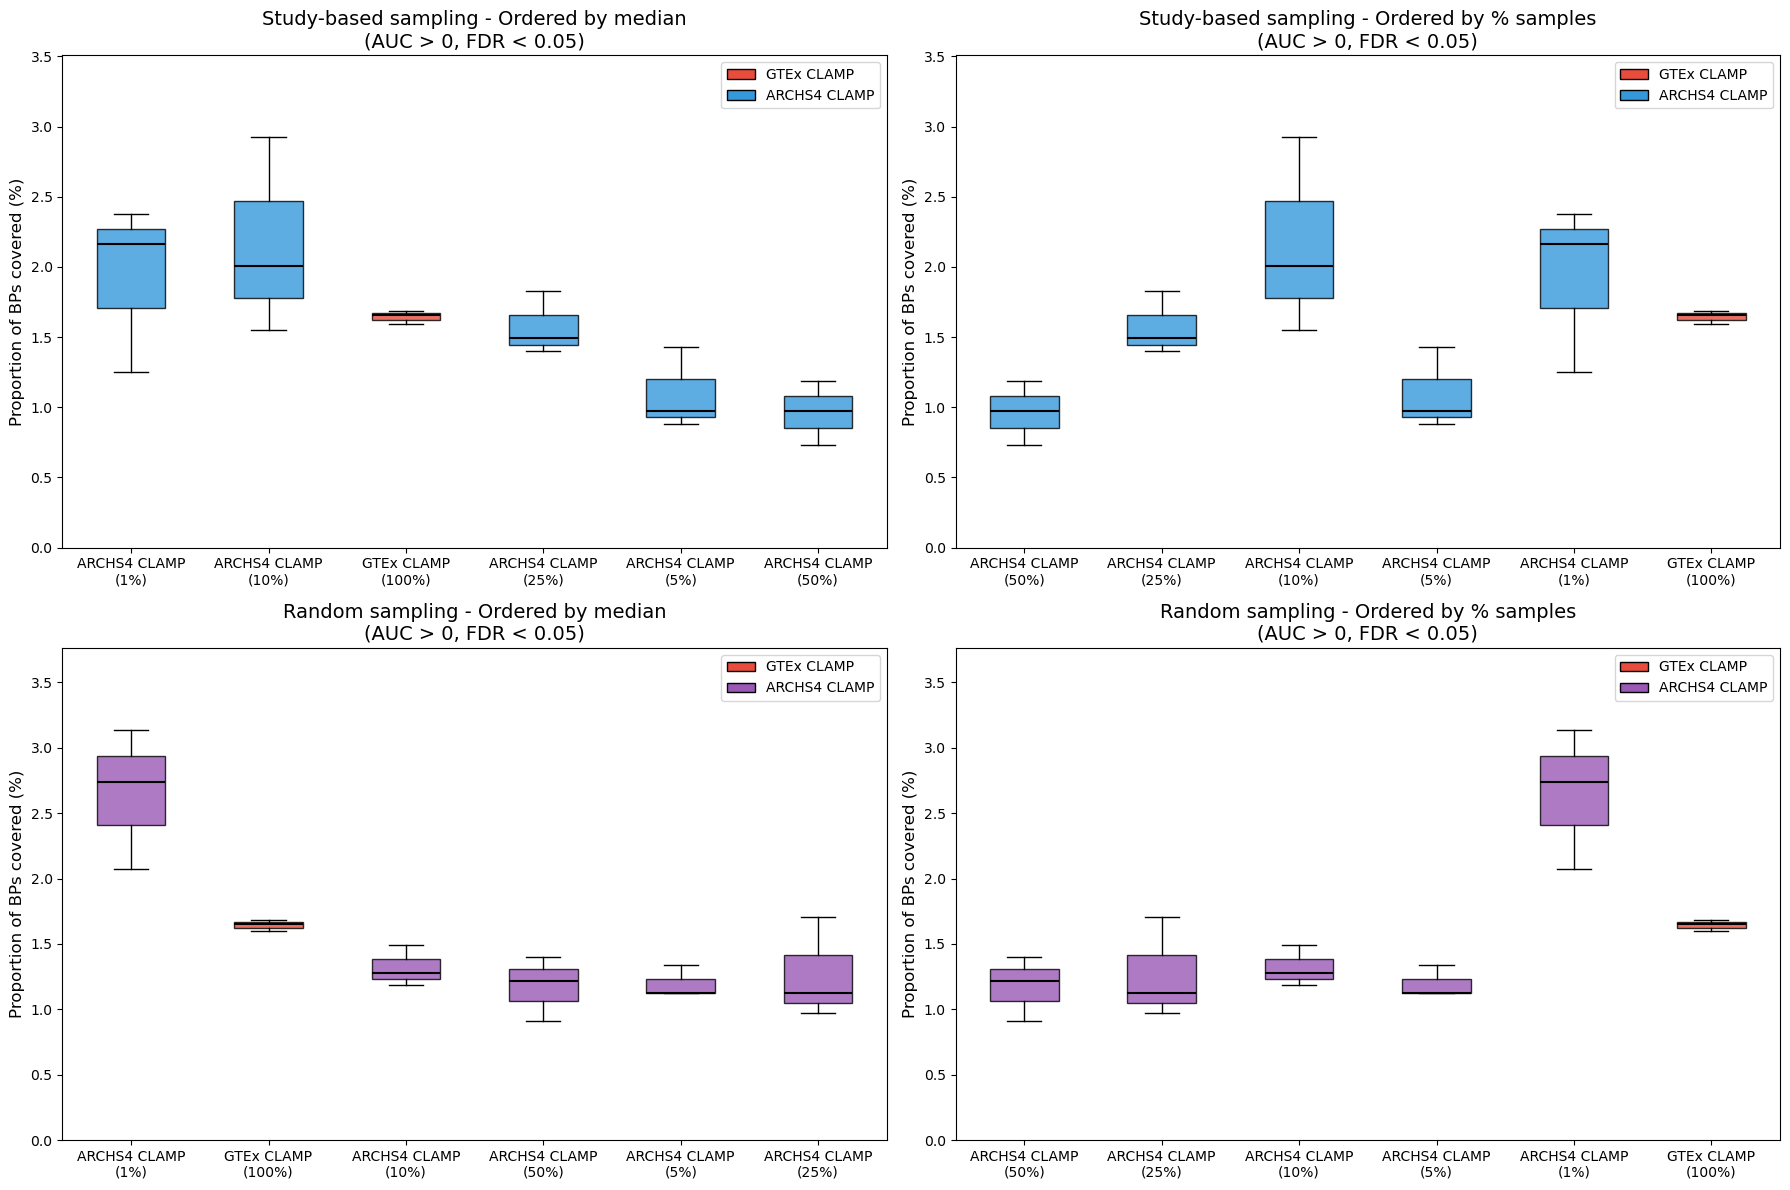

In [10]:
study_005, random_005, gtex_005 = process_data(
    bp_coverage_files, bp_coverage_rs_files, gtex_seed_paths,
    total_bps_archs4, total_bps_gtex, fdr_thr=0.05, auc_thr=0
)
make_all_plots(study_005, random_005, gtex_005, fdr_thr=0.05, auc_thr=0)

### FDR < 0.1, AUC > 0.6

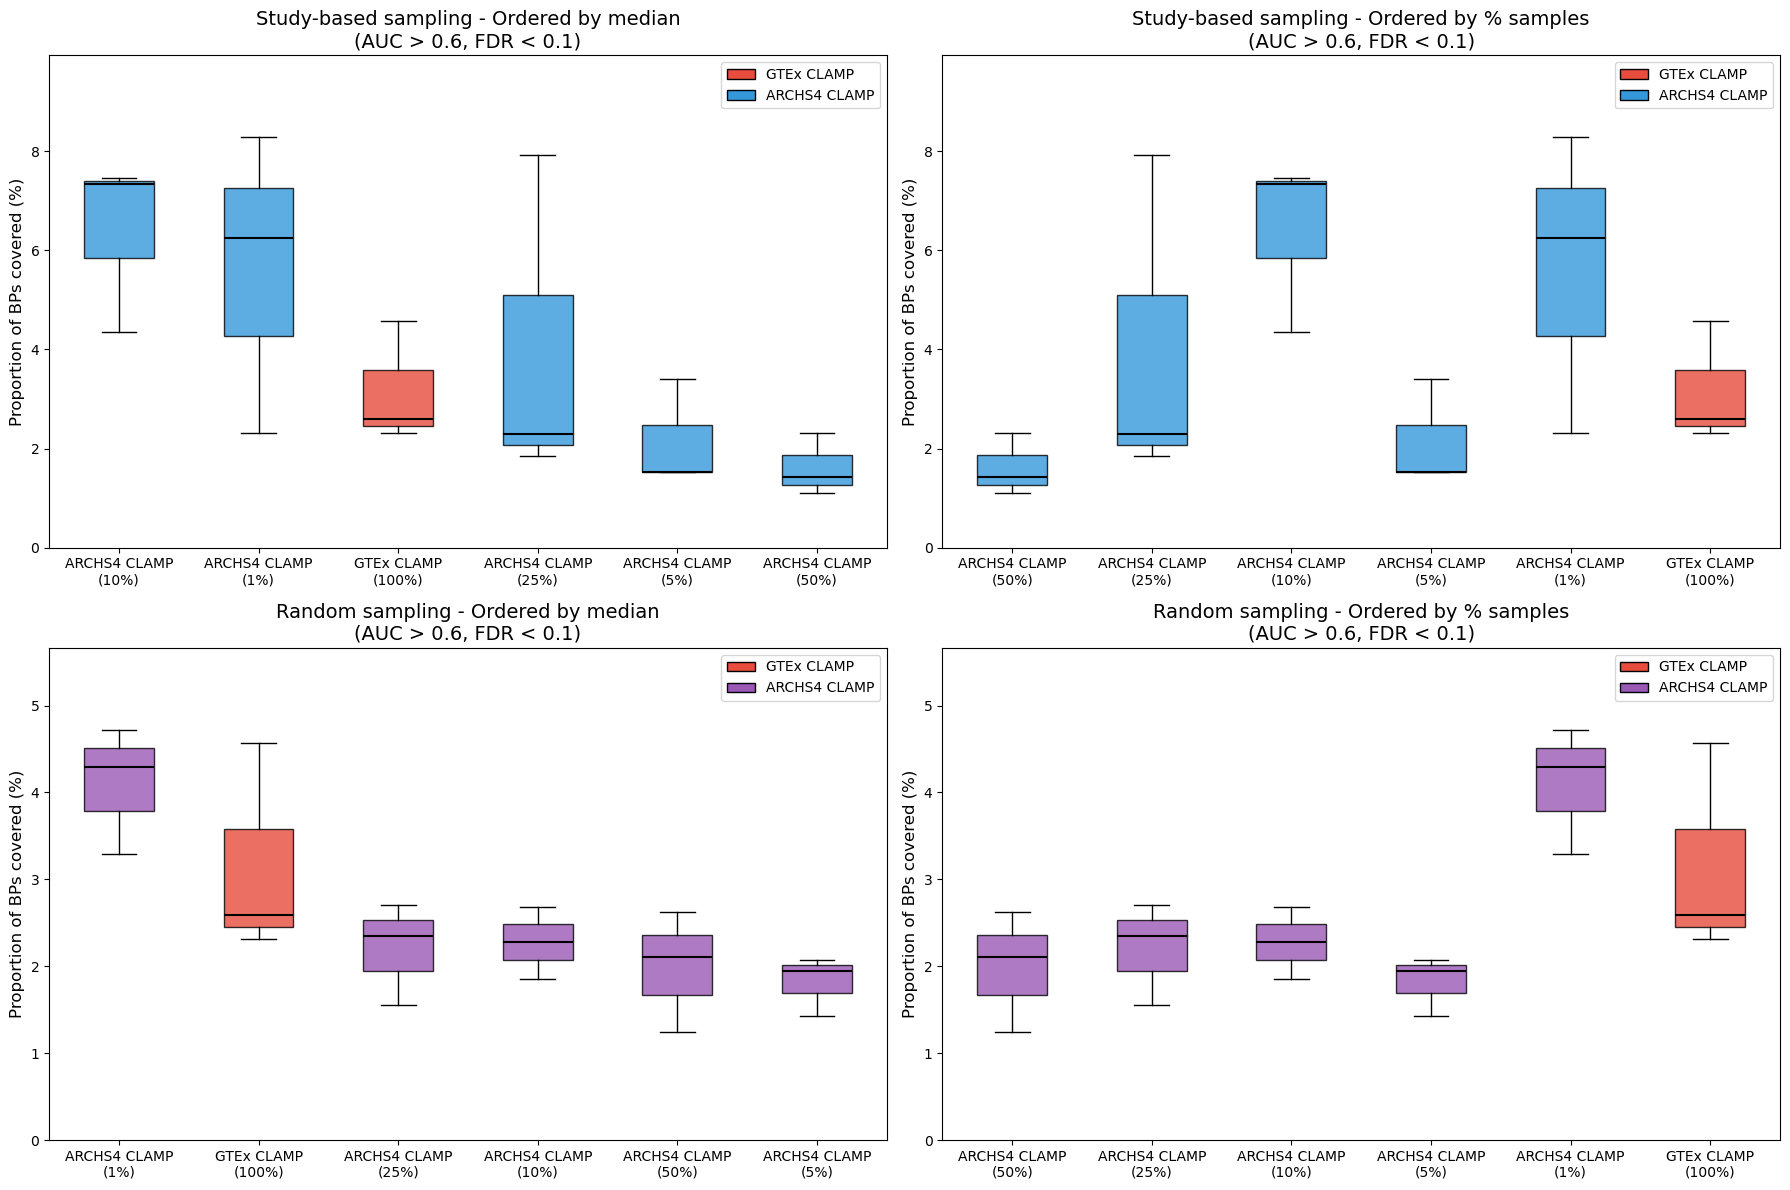

In [11]:
study_01, random_01, gtex_01 = process_data(
    bp_coverage_files, bp_coverage_rs_files, gtex_seed_paths,
    total_bps_archs4, total_bps_gtex, fdr_thr=0.1, auc_thr=0.6
)
make_all_plots(study_01, random_01, gtex_01, fdr_thr=0.1, auc_thr=0.6)

In [12]:
import pandas as pd
import os
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from pyprojroot.here import here

readRDS = ro.r["readRDS"]

base_dir = here("output/archs4")

coverages = [1, 5, 10, 25, 50]
seeds = [1, 2, 3]

results = []

for coverage in coverages:
    for seed in seeds:
        # Non-rs path
        path_nrs = os.path.join(base_dir, f"bp_coverage_{coverage}_seed_{seed}", "CLAMP_K.rds")
        # RS path
        path_rs = os.path.join(base_dir, f"bp_coverage_rs{coverage}_seed_{seed}", "CLAMP_K.rds")
        
        # Read values
        K_nrs = readRDS(path_nrs)[0] if os.path.exists(path_nrs) else None
        K_rs = readRDS(path_rs)[0] if os.path.exists(path_rs) else None
        
        results.append({
            'coverage': coverage,
            'seed': seed,
            'CLAMP_K_studybased_sampling': K_nrs,
            'CLAMP_K_random_sampling': K_rs
        })

df = pd.DataFrame(results).sort_values(['coverage', 'seed'])
print(df.to_string(index=False))

 coverage  seed  CLAMP_K_studybased_sampling  CLAMP_K_random_sampling
        1     1                        744.0                   1084.0
        1     2                        654.0                    936.0
        1     3                        756.0                   1146.0
        5     1                       1618.0                   2312.0
        5     2                       1996.0                   2324.0
        5     3                       1838.0                   1586.0
       10     1                         60.0                   1136.0
       10     2                        352.0                   2546.0
       10     3                        332.0                   2214.0
       25     1                        904.0                    978.0
       25     2                       1942.0                    684.0
       25     3                        520.0                   1902.0
       50     1                       2738.0                   2022.0
       50     2     

In [13]:
# svd_10_1 = readRDS(f"{base_dir}/bp_coverage_10_seed_1/svd.rds")
# svd_10_2 = readRDS(f"{base_dir}/bp_coverage_10_seed_2/svd.rds")
# svd_10_3 = readRDS(f"{base_dir}/bp_coverage_10_seed_3/svd.rds")

# # Extract singular values
# d_10_1 = list(svd_10_1.rx2("d"))
# d_10_2 = list(svd_10_2.rx2("d"))
# d_10_3 = list(svd_10_3.rx2("d"))

# # Plot singular values
# plt.figure(figsize=(10, 6))

# plt.plot(d_10_1[:500], label=f'Seed 1 (K=60)', color='red')
# plt.plot(d_10_2[:500], label=f'Seed 2 (K=352)', color='blue')
# plt.plot(d_10_3[:500], label=f'Seed 3 (K=332)', color='green')

# plt.xlabel('Latent Variable (LV)', fontsize=12)
# plt.ylabel('Singular Value (σ)', fontsize=12)
# plt.legend(fontsize=11)
# plt.tight_layout()
# plt.show()

In [14]:
# import os
# import pandas as pd
# import matplotlib.pyplot as plt
# import rpy2.robjects as ro
# from pyprojroot import here

# readRDS = ro.r["readRDS"]

# seeds = [1, 2, 3]

# # Read CLAMP_K values
# results_gtex_k = []
# for seed in seeds:
#     path_k = here(f"output/gtex/bp_coverage_seed_{seed}/CLAMP_K.rds")
#     K = readRDS(str(path_k))[0] if os.path.exists(path_k) else None
#     results_gtex_k.append({'seed': seed, 'CLAMP_K': K})

# df_gtex_k = pd.DataFrame(results_gtex_k)
# print("GTEx CLAMP_K values:")
# print(df_gtex_k.to_string(index=False))

# # Read SVD and plot singular values
# svd_1 = readRDS(str(here("output/gtex/bp_coverage_seed_1/svd.rds")))
# svd_2 = readRDS(str(here("output/gtex/bp_coverage_seed_2/svd.rds")))
# svd_3 = readRDS(str(here("output/gtex/bp_coverage_seed_3/svd.rds")))

# d_1 = list(svd_1.rx2("d"))
# d_2 = list(svd_2.rx2("d"))
# d_3 = list(svd_3.rx2("d"))

# # Plot
# plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
# plt.plot(d_1[:200], label=f'seed 1 (K={df_gtex_k.loc[0, "CLAMP_K"]})', color='red')
# plt.plot(d_2[:200], label=f'seed 2 (K={df_gtex_k.loc[1, "CLAMP_K"]})', color='blue')
# plt.plot(d_3[:200], label=f'seed 3 (K={df_gtex_k.loc[2, "CLAMP_K"]})', color='green')
# plt.xlabel('Index')
# plt.ylabel('Singular value')
# plt.title('GTEx - Singular values')
# plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(d_1[:200], label='seed 1', color='red')
# plt.plot(d_2[:200], label='seed 2', color='blue')
# plt.plot(d_3[:200], label='seed 3', color='green')
# plt.xlabel('Index')
# plt.ylabel('Singular value (log scale)')
# plt.yscale('log')
# plt.title('GTEx - Log scale')
# plt.legend()

# plt.tight_layout()
# plt.show()

# # Print lengths
# print(f"\nLength of singular values:")
# print(f"  seed 1: {len(d_1)}")
# print(f"  seed 2: {len(d_2)}")
# print(f"  seed 3: {len(d_3)}")

## K (number of LVs) by sample coverage

Full ARCHS4 model K: 2366


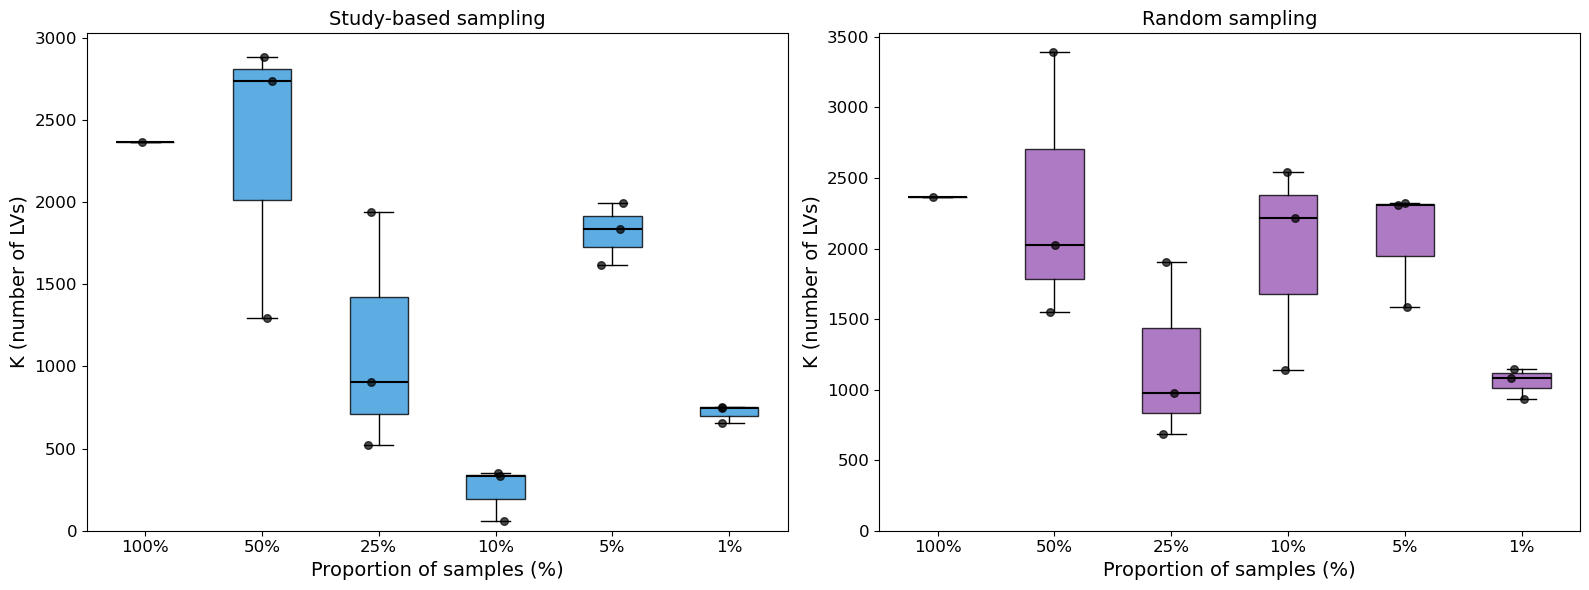

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rpy2.robjects as ro
from pyprojroot import here

readRDS = ro.r["readRDS"]

# Load K for full ARCHS4 model (100% samples, 1 repetition)
full_k_path = here("output/archs4/CLAMP_K_archs4.rds")
K_full_archs4 = int(readRDS(str(full_k_path))[0]) if os.path.exists(str(full_k_path)) else None
print(f"Full ARCHS4 model K: {K_full_archs4}")

coverage_levels = [100, 50, 25, 10, 5, 1]
coverage_labels  = ["100%", "50%", "25%", "10%", "5%", "1%"]

# K values per coverage group (study-based and random sampling)
study_k  = {100: [K_full_archs4]}
random_k = {100: [K_full_archs4]}
for cov in [50, 25, 10, 5, 1]:
    study_k[cov]  = df[df["coverage"] == cov]["CLAMP_K_studybased_sampling"].dropna().tolist()
    random_k[cov] = df[df["coverage"] == cov]["CLAMP_K_random_sampling"].dropna().tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

np.random.seed(42)
for ax, k_data, title, color in [
    (axes[0], study_k,  "Study-based sampling", "#3498db"),
    (axes[1], random_k, "Random sampling",       "#9b59b6"),
]:
    all_data   = [k_data[cov] for cov in coverage_levels]
    all_labels = coverage_labels
    all_colors = [color] * len(coverage_levels)

    bp = ax.boxplot(
        all_data, positions=range(len(all_data)), widths=0.5,
        patch_artist=True, showfliers=True,
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(color="black"), capprops=dict(color="black"),
    )
    for patch, c in zip(bp["boxes"], all_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)

    for i, data in enumerate(all_data):
        jitter = np.random.uniform(-0.1, 0.1, len(data))
        ax.scatter(np.full(len(data), i) + jitter, data,
                   color="black", s=30, alpha=0.7, zorder=5)

    ax.set_xticks(range(len(all_labels)))
    ax.set_xticklabels(all_labels, fontsize=12)
    ax.set_ylabel("K (number of LVs)", fontsize=14)
    ax.set_xlabel("Proportion of samples (%)", fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.set_ylim(0, None)
    ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.show()